# From Empty Seats to Higher Revenue
## An XGBoost Attendance Prediction Model for Charlotte Hornets Game-Day Revenue

### Business Framing
The Charlotte Hornets can reduce revenue volatility by predicting low-demand home games early and deploying targeted interventions (promotions, bundled offers, dynamic pricing, and fan-engagement campaigns) before seats go unsold.

### Modeling Objective
Build a production-style attendance forecasting workflow that:
1. Predicts home-game attendance using game context, schedule context, opponent strength proxies, and weather.
2. Identifies the strongest attendance drivers.
3. Flags high-risk low-demand games for operations teams.
4. Quantifies potential revenue recovery under intervention scenarios.

### What This Notebook Produces
- Cleaned and integrated game + All-Star + weather dataset.
- Feature engineering tailored for business interpretability.
- XGBoost model tuned with GridSearchCV.
- Test-set model performance and explainability outputs.
- Presentation-ready tables that replace placeholder PowerPoint numbers with model-based values.


## Notebook Organization
1. Setup and reproducibility
2. Data loading and inspection
3. Cleaning and integration
4. Feature engineering
5. EDA for business storytelling
6. XGBoost + GridSearchCV modeling
7. Model evaluation and interpretation
8. Business insight extraction
9. Revenue opportunity scenario modeling
10. High-risk game flagging
11. Presentation numbers to update


In [1]:
# Core setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import datetime
import re

from sklearn.model_selection import TimeSeriesSplit, train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

# Optional explainability package
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(42)


### Install Note
If any package import fails locally, install dependencies and rerun:
- pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, shap


In [2]:
# File location helpers (defensive against folder differences)
ROOT = Path.cwd()
CANDIDATE_DIRS = [ROOT, ROOT / "data"]

def locate_file(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not locate {filename} in {CANDIDATE_DIRS}")

GAMES_PATH = locate_file("hornets_games_2015-2026.csv")
ALL_STARS_PATH = locate_file("nba_all_stars.csv")
WEATHER_PATH = locate_file("weather_data.csv")

print("Games:", GAMES_PATH)
print("All-Stars:", ALL_STARS_PATH)
print("Weather:", WEATHER_PATH)


Games: c:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6276-Hornets-Analysis\data\hornets_games_2015-2026.csv
All-Stars: c:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6276-Hornets-Analysis\data\nba_all_stars.csv
Weather: c:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6276-Hornets-Analysis\data\weather_data.csv


In [3]:
# Load data
raw_games = pd.read_csv(GAMES_PATH)
raw_all_stars = pd.read_csv(ALL_STARS_PATH)
raw_weather = pd.read_csv(WEATHER_PATH)

def inspect_df(name: str, df: pd.DataFrame):
    print(f"\n{'='*90}\n{name}\n{'='*90}")
    print(f"Shape: {df.shape}")
    display(df.head(5))
    display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss) == 0:
        print("Missing values: none")
    else:
        display(miss.to_frame("missing_count"))

inspect_df("Hornets Games", raw_games)
inspect_df("NBA All-Stars", raw_all_stars)
inspect_df("Weather", raw_weather)



Hornets Games
Shape: (954, 24)


,game_id,date,opponent,city,state,arena,attendance,capacity,attendance_percent,hornets_wins,hornets_losses,opponent_wins,opponent_losses,hornets_score,opponent_score,location,hornets_top_scorer (points),opponents_top_scorer,hornets_most_assists,opponents_most_assists,hornets_top_rebounder,opponents_top_rebounder,season,opponent_all_stars_count
0,400579520,04/15/2015,Toronto Raptors,Toronto,ON,Scotiabank Arena,19800,19800,100.00,33,49,49,33,87,92,Away,Troy Daniels (24),Kyle Lowry (26),Brian Roberts (5),Kyle Lowry (7),Noah Vonleh (12),Amir Johnson (6),2015,0
1,400578422,11/15/2014,Phoenix Suns,Phoenix,AZ,Mortgage Matchup Center,16291,18422,88.40,4,5,5,4,103,95,Away,Kemba Walker (19),Eric Bledsoe (22),Lance Stephenson (7),Eric Bledsoe (5),Bismack Biyombo (10),Eric Bledsoe (11),2015,0
2,400578452,11/20/2014,Indiana Pacers,Indianapolis,IN,Gainbridge Fieldhouse,14748,17923,82.30,4,8,5,7,86,88,Away,Al Jefferson (28),Roy Hibbert (18),Kemba Walker (7),Donald Sloan (6),Al Jefferson (8),Roy Hibbert (11),2015,0
3,400579226,03/08/2015,Detroit Pistons,Auburn Hills,MI,The Palace of Auburn Hills,15673,22076,71.00,28,33,23,39,108,101,Away,Al Jefferson (24),Reggie Jackson (25),Mo Williams (9),Reggie Jackson (7),Al Jefferson (8),Greg Monroe (11),2015,0
4,400579468,04/10/2015,Atlanta Hawks,Atlanta,GA,State Farm Arena,18462,16600,111.20,33,46,60,19,80,104,Away,Troy Daniels (15),Mike Muscala (17),Kemba Walker (6),Jeff Teague (8),Bismack Biyombo (11),Al Horford (8),2015,0


,column,dtype
0,game_id,int64
1,date,object
2,opponent,object
3,city,object
4,state,object
5,arena,object
6,attendance,int64
7,capacity,int64
8,attendance_percent,float64
9,hornets_wins,int64


,missing_count
attendance_percent,38
hornets_top_rebounder,23
hornets_top_scorer (points),23
opponents_top_scorer,23
hornets_most_assists,23
opponents_top_rebounder,23
opponents_most_assists,23
state,1



NBA All-Stars
Shape: (193, 4)


...

,column,dtype
0,Year,int64
1,Player,object
2,Team,object
3,Position,object


Missing values: none

Weather
Shape: (476, 8)


,date,game_id,temp_high,temp_low,precipitation,wind_speed,windy,weather_description
0,2014-12-28,400578736,58.80,46.90,0.21,11.10,0,Drizzle
1,2015-01-25,400578944,54.20,27.90,0.00,9.40,0,Partly cloudy
2,2014-12-04,400578555,58.80,45.90,0.00,7.50,0,Partly cloudy
3,2015-01-22,400578917,55.90,35.20,0.00,5.70,0,Partly cloudy
4,2014-12-23,400578701,44.30,37.20,0.44,7.30,0,Rain


,column,dtype
0,date,object
1,game_id,int64
2,temp_high,float64
3,temp_low,float64
4,precipitation,float64
5,wind_speed,float64
6,windy,int64
7,weather_description,object


Missing values: none


### Inspection Observations
- The games file includes both home and away rows, so home-game filtering is required.
- Weather rows are fewer than total games, consistent with home-only weather capture and/or missing weather records.
- All-Star data is season-level by team and player, useful for opponent star-power aggregation.
- Column names are generally clean, but defensive logic is used to handle naming variation.


In [4]:
# Utility functions for robust column matching and team name normalization

def normalize_col(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c


def find_col(df: pd.DataFrame, candidates):
    norm_map = {normalize_col(c): c for c in df.columns}
    for cand in candidates:
        nc = normalize_col(cand)
        if nc in norm_map:
            return norm_map[nc]
    # fallback: partial match
    for nc, orig in norm_map.items():
        for cand in candidates:
            if normalize_col(cand) in nc:
                return orig
    return None

TEAM_ALIAS = {
    "la clippers": "los angeles clippers",
    "los angeles clippers": "los angeles clippers",
    "la lakers": "los angeles lakers",
    "los angeles lakers": "los angeles lakers",
    "brooklyn": "brooklyn nets",
    "new jersey nets": "brooklyn nets",
    "oklahoma city": "oklahoma city thunder",
    "golden state": "golden state warriors",
    "new orleans": "new orleans pelicans",
    "phoenix": "phoenix suns",
    "san antonio": "san antonio spurs",
    "portland": "portland trail blazers",
    "utah": "utah jazz",
    "minnesota": "minnesota timberwolves",
    "indiana": "indiana pacers",
    "orlando": "orlando magic",
    "washington": "washington wizards",
    "charlotte": "charlotte hornets",
}


def clean_team_name(x: str) -> str:
    if pd.isna(x):
        return np.nan
    t = str(x).strip().lower()
    t = re.sub(r"[^a-z\s]", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    if t in TEAM_ALIAS:
        return TEAM_ALIAS[t]
    # Convert common short forms to full names when possible
    tokens = t.split()
    if len(tokens) == 1 and t in TEAM_ALIAS:
        return TEAM_ALIAS[t]
    return t


In [5]:
# Clean games data
games = raw_games.copy()

# Parse date safely
date_col = find_col(games, ["date", "game_date"])
if date_col is None:
    raise ValueError("No date column found in games data.")
games["date"] = pd.to_datetime(games[date_col], errors="coerce")

# Deduplicate
games_before = len(games)
games = games.drop_duplicates()
games_after = len(games)

# Home game filtering
location_col = find_col(games, ["location", "home_away"])
if location_col is not None:
    games[location_col] = games[location_col].astype(str)
    home_games = games[games[location_col].str.lower().str.contains("home", na=False)].copy()
else:
    home_games = games.copy()

# Essential columns mapping
game_id_col = find_col(home_games, ["game_id", "id"])
attendance_col = find_col(home_games, ["attendance", "crowd", "tickets"])
opponent_col = find_col(home_games, ["opponent", "opp", "away_team", "visitor_team"])
season_col = find_col(home_games, ["season", "year", "season_year"])

if attendance_col is None or opponent_col is None:
    raise ValueError("Attendance or opponent column missing after mapping.")

home_games["attendance"] = pd.to_numeric(home_games[attendance_col], errors="coerce")
home_games["opponent"] = home_games[opponent_col].astype(str)
home_games["opponent_clean"] = home_games["opponent"].apply(clean_team_name)

if season_col is None:
    home_games["season"] = home_games["date"].dt.year
else:
    home_games["season"] = pd.to_numeric(home_games[season_col], errors="coerce")

# Validate disruptions by home-game counts per season (do not hardcode)
season_counts = home_games.groupby("season", dropna=True).size().rename("home_games").reset_index()
median_home_games = season_counts["home_games"].median()
# Heuristic: season with < 70% of median home games considered likely partial/disrupted
threshold = 0.70 * median_home_games
flagged_seasons = season_counts.loc[season_counts["home_games"] < threshold, "season"].tolist()

# Keep all rows by default for transparency; create a modeling subset that excludes clearly partial seasons
model_games = home_games.copy()
if len(flagged_seasons) > 0:
    model_games = model_games[~model_games["season"].isin(flagged_seasons)].copy()

print(f"Rows before dedupe: {games_before:,}; after dedupe: {games_after:,}")
print(f"Home-game rows retained: {len(home_games):,}")
print("Potentially partial/disrupted seasons (heuristic):", flagged_seasons)
print(f"Rows in modeling subset after optional season filter: {len(model_games):,}")
display(season_counts.sort_values("season"))


Rows before dedupe: 954; after dedupe: 954
Home-game rows retained: 476
Potentially partial/disrupted seasons (heuristic): []
Rows in modeling subset after optional season filter: 476


,season,home_games
0,2015,41
1,2016,41
2,2017,41
3,2018,41
4,2019,41
5,2020,31
6,2021,36
7,2022,41
8,2023,41
9,2024,41


### Cleaning Notes
- Dates are parsed with coercion to handle malformed values safely.
- Duplicates are removed before downstream merges.
- Home games are filtered when a location field is available.
- Potentially partial/disrupted seasons are detected empirically from game counts; exclusion is data-driven rather than hardcoded.


In [6]:
# Prepare All-Star aggregation by team-season
all_stars = raw_all_stars.copy()
all_stars.columns = [c.strip() for c in all_stars.columns]

as_year_col = find_col(all_stars, ["year", "season", "season_year"])
as_team_col = find_col(all_stars, ["team", "team_name"])

if as_year_col is None or as_team_col is None:
    all_star_team_year = pd.DataFrame(columns=["season", "opponent_clean", "all_star_count_from_file"])
else:
    all_stars["season"] = pd.to_numeric(all_stars[as_year_col], errors="coerce")
    all_stars["opponent_clean"] = all_stars[as_team_col].apply(clean_team_name)
    all_star_team_year = (
        all_stars.dropna(subset=["season", "opponent_clean"])
        .groupby(["season", "opponent_clean"], as_index=False)
        .size()
        .rename(columns={"size": "all_star_count_from_file"})
    )

# Prepare weather
weather = raw_weather.copy()
weather_date_col = find_col(weather, ["date", "game_date"])
weather_gid_col = find_col(weather, ["game_id", "id"])

if weather_date_col is not None:
    weather["date"] = pd.to_datetime(weather[weather_date_col], errors="coerce")

if weather_gid_col is not None:
    weather["game_id"] = pd.to_numeric(weather[weather_gid_col], errors="coerce")

# Merge strategy: game_id first where possible, else date
base = model_games.copy()
base["game_id"] = pd.to_numeric(base[game_id_col], errors="coerce") if game_id_col is not None else np.nan

pre_merge_rows = len(base)
if "game_id" in weather.columns and weather["game_id"].notna().any() and base["game_id"].notna().any():
    merged = base.merge(weather, on="game_id", how="left", suffixes=("", "_wx"))
    merge_key_used = "game_id"
else:
    merged = base.merge(weather, on="date", how="left", suffixes=("", "_wx"))
    merge_key_used = "date"

post_weather_rows = len(merged)

# Merge All-Star season + opponent key
merged = merged.merge(all_star_team_year, on=["season", "opponent_clean"], how="left")
post_allstar_rows = len(merged)

# Resolve all-star count from either source file or games file
raw_opp_as_col = find_col(merged, ["opponent_all_stars_count", "opp_all_stars", "all_star_count"])
merged["opponent_all_stars_count_final"] = merged["all_star_count_from_file"]
if raw_opp_as_col is not None:
    merged["opponent_all_stars_count_final"] = merged["opponent_all_stars_count_final"].fillna(
        pd.to_numeric(merged[raw_opp_as_col], errors="coerce")
    )
merged["opponent_all_stars_count_final"] = merged["opponent_all_stars_count_final"].fillna(0)

# Merge diagnostics
weather_match_rate = merged.filter(regex="temp_high|temp_low|precipitation|weather_description").notna().any(axis=1).mean()
allstar_match_rate = merged["all_star_count_from_file"].notna().mean() if "all_star_count_from_file" in merged.columns else 0.0

print("Merge key used for weather:", merge_key_used)
print(f"Rows: pre-merge={pre_merge_rows:,}, after weather merge={post_weather_rows:,}, after all-star merge={post_allstar_rows:,}")
print(f"Weather match rate: {weather_match_rate:.1%}")
print(f"All-Star season-team match rate: {allstar_match_rate:.1%}")

display(merged.head(3))


Merge key used for weather: game_id
Rows: pre-merge=476, after weather merge=476, after all-star merge=476
Weather match rate: 100.0%
All-Star season-team match rate: 41.8%


,game_id,date,opponent,city,state,arena,attendance,capacity,attendance_percent,hornets_wins,hornets_losses,opponent_wins,opponent_losses,hornets_score,opponent_score,location,hornets_top_scorer (points),opponents_top_scorer,hornets_most_assists,opponents_most_assists,hornets_top_rebounder,opponents_top_rebounder,season,opponent_all_stars_count,opponent_clean,date_wx,temp_high,temp_low,precipitation,wind_speed,windy,weather_description,all_star_count_from_file,opponent_all_stars_count_final
0,400578736,2014-12-28,Orlando Magic,Charlotte,NC,Spectrum Center,19085,19077,100.00,10,21,12,21,94,102,Home,Kemba Walker (42),Nikola Vucevic (22),Kemba Walker (7),Elfrid Payton (8),Al Jefferson (9),Nikola Vucevic (11),2015,0,orlando magic,2014-12-28,58.80,46.90,0.21,11.10,0,Drizzle,NaN,0.00
1,400578944,2015-01-25,New York Knicks,Charlotte,NC,Spectrum Center,19117,19077,100.20,19,26,8,37,76,71,Home,Brian Roberts (17),Tim Hardaway Jr. (25),Lance Stephenson (4),Tim Hardaway Jr. (5),Cody Zeller (8),Cole Aldrich (13),2015,0,new york knicks,2015-01-25,54.20,27.90,0.00,9.40,0,Partly cloudy,NaN,0.00
2,400578555,2014-12-04,Chicago Bulls,Charlotte,NC,Spectrum Center,16887,19077,88.50,4,15,12,7,95,102,Home,NaN,NaN,NaN,NaN,NaN,NaN,2015,1,chicago bulls,2014-12-04,58.80,45.90,0.00,7.50,0,Partly cloudy,1.00,1.00


In [7]:
# Feature engineering
model_df = merged.copy()

# Date/time features
model_df["game_date"] = pd.to_datetime(model_df["date"], errors="coerce")
model_df = model_df.sort_values("game_date").reset_index(drop=True)
model_df["year"] = model_df["game_date"].dt.year
model_df["month"] = model_df["game_date"].dt.month
model_df["day_of_week"] = model_df["game_date"].dt.day_name()
model_df["is_weekend"] = model_df["day_of_week"].isin(["Friday", "Saturday", "Sunday"]).astype(int)
model_df["is_weekday"] = 1 - model_df["is_weekend"]
model_df["is_holiday_window"] = model_df["month"].isin([11, 12, 1]).astype(int)
model_df["is_school_break_proxy"] = model_df["month"].isin([12, 6, 7, 8]).astype(int)

# Days since previous home game
model_df["days_since_prev_home_game"] = model_df["game_date"].diff().dt.days
model_df["days_since_prev_home_game"] = model_df["days_since_prev_home_game"].fillna(model_df["days_since_prev_home_game"].median())
model_df["dense_schedule_flag"] = (model_df["days_since_prev_home_game"] <= 2).astype(int)

# Opponent quality and matchup flags
model_df["opponent_all_stars_count_final"] = pd.to_numeric(model_df["opponent_all_stars_count_final"], errors="coerce").fillna(0)
model_df["opponent_has_all_star"] = (model_df["opponent_all_stars_count_final"] > 0).astype(int)

# Tier from all-star count quantiles
q1 = model_df["opponent_all_stars_count_final"].quantile(0.33)
q2 = model_df["opponent_all_stars_count_final"].quantile(0.67)

def opp_tier(x):
    if x <= q1:
        return "weak"
    if x <= q2:
        return "mid"
    return "marquee"

model_df["opponent_quality_tier"] = model_df["opponent_all_stars_count_final"].apply(opp_tier)
model_df["is_marquee_opponent"] = (model_df["opponent_quality_tier"] == "marquee").astype(int)
model_df["is_weak_opponent"] = (model_df["opponent_quality_tier"] == "weak").astype(int)
model_df["premium_matchup_flag"] = ((model_df["is_marquee_opponent"] == 1) & (model_df["is_weekend"] == 1)).astype(int)

# Optional team-strength context if available
hornets_w_col = find_col(model_df, ["hornets_wins", "team_wins"])
hornets_l_col = find_col(model_df, ["hornets_losses", "team_losses"])
opp_w_col = find_col(model_df, ["opponent_wins", "opp_wins"])
opp_l_col = find_col(model_df, ["opponent_losses", "opp_losses"])

if all(c is not None for c in [hornets_w_col, hornets_l_col]):
    hw = pd.to_numeric(model_df[hornets_w_col], errors="coerce")
    hl = pd.to_numeric(model_df[hornets_l_col], errors="coerce")
    model_df["hornets_win_pct_proxy"] = hw / (hw + hl).replace({0: np.nan})
else:
    model_df["hornets_win_pct_proxy"] = np.nan

if all(c is not None for c in [opp_w_col, opp_l_col]):
    ow = pd.to_numeric(model_df[opp_w_col], errors="coerce")
    ol = pd.to_numeric(model_df[opp_l_col], errors="coerce")
    model_df["opponent_win_pct_proxy"] = ow / (ow + ol).replace({0: np.nan})
else:
    model_df["opponent_win_pct_proxy"] = np.nan

# Weather features
for col in ["temp_high", "temp_low", "precipitation", "wind_speed", "windy"]:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    else:
        model_df[col] = np.nan

model_df["avg_temp"] = model_df[["temp_high", "temp_low"]].mean(axis=1)
model_df["rain_flag"] = (model_df["precipitation"].fillna(0) > 0).astype(int)
model_df["bad_weather_flag"] = (
    (model_df["precipitation"].fillna(0) >= model_df["precipitation"].fillna(0).quantile(0.70)) |
    (model_df["wind_speed"].fillna(0) >= model_df["wind_speed"].fillna(0).quantile(0.70))
).astype(int)
model_df["severe_weather_flag"] = (
    (model_df["precipitation"].fillna(0) >= model_df["precipitation"].fillna(0).quantile(0.90)) |
    (model_df["wind_speed"].fillna(0) >= model_df["wind_speed"].fillna(0).quantile(0.90))
).astype(int)

# Categorical weather buckets if description exists
if "weather_description" in model_df.columns:
    wd = model_df["weather_description"].fillna("Unknown").astype(str).str.lower()
    model_df["weather_bucket"] = np.select(
        [
            wd.str.contains("rain|drizzle|storm|thunder|snow"),
            wd.str.contains("cloud|overcast|fog|mist"),
            wd.str.contains("sun|clear|fair|partly")
        ],
        ["precip", "cloudy", "clear"],
        default="other"
    )
else:
    model_df["weather_bucket"] = "unknown"

# Interaction features
model_df["weekday_x_weak_opp"] = model_df["is_weekday"] * model_df["is_weak_opponent"]
model_df["weekday_x_bad_weather"] = model_df["is_weekday"] * model_df["bad_weather_flag"]
model_df["non_marquee_x_bad_weather"] = (1 - model_df["is_marquee_opponent"]) * model_df["bad_weather_flag"]
model_df["weekend_x_marquee"] = model_df["is_weekend"] * model_df["is_marquee_opponent"]
model_df["weak_opp_x_rain"] = model_df["is_weak_opponent"] * model_df["rain_flag"]

# Final target clean-up
model_df["attendance"] = pd.to_numeric(model_df["attendance"], errors="coerce")
model_df = model_df.dropna(subset=["attendance", "game_date"]).copy()

print("Modeling dataset shape:", model_df.shape)
display(model_df[["game_date", "opponent", "attendance", "opponent_quality_tier", "is_weekend", "rain_flag", "bad_weather_flag"]].head())


Modeling dataset shape: (476, 61)


,game_date,opponent,attendance,opponent_quality_tier,is_weekend,rain_flag,bad_weather_flag
0,2014-10-29,Milwaukee Bucks,19439,weak,0,1,0
1,2014-11-01,Memphis Grizzlies,18133,mid,1,1,1
2,2014-11-06,Miami Heat,15874,weak,0,1,1
3,2014-11-08,Atlanta Hawks,15891,weak,1,0,0
4,2014-11-18,Dallas Mavericks,15345,weak,0,0,0


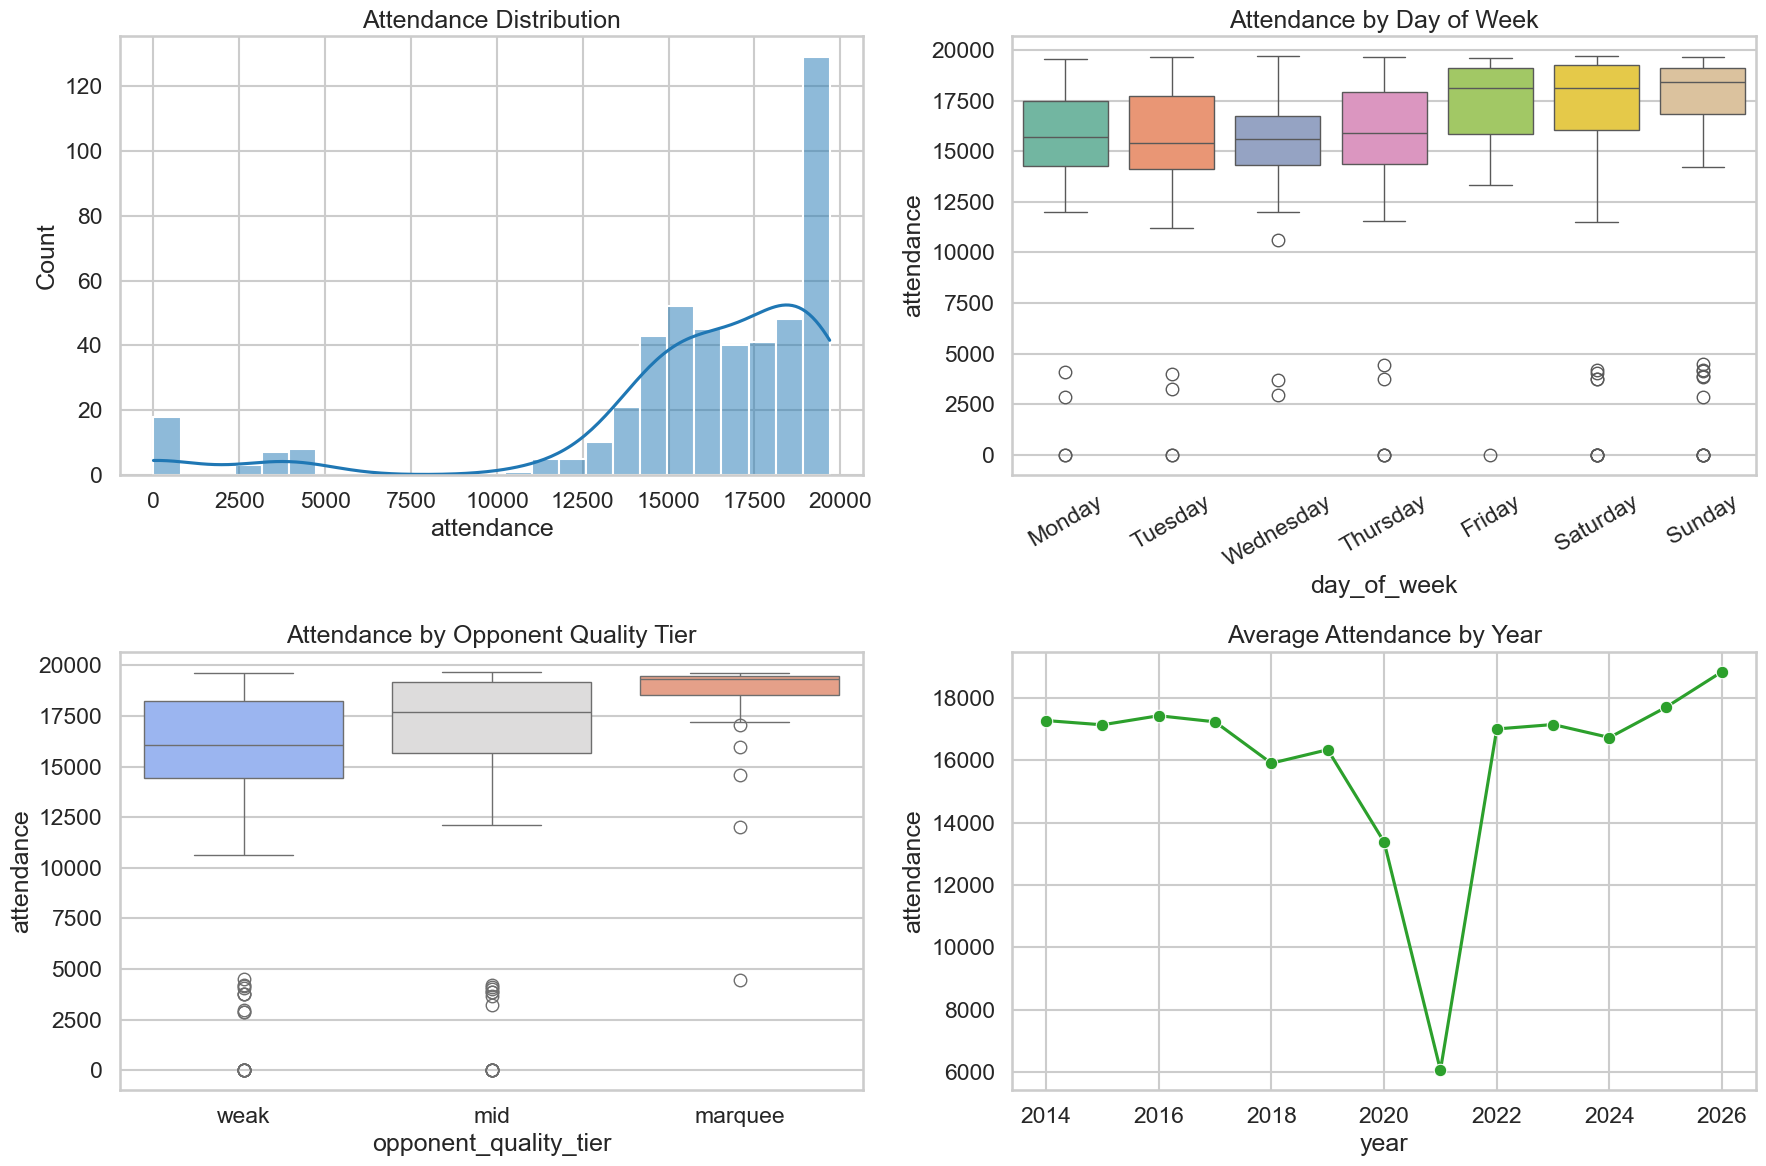

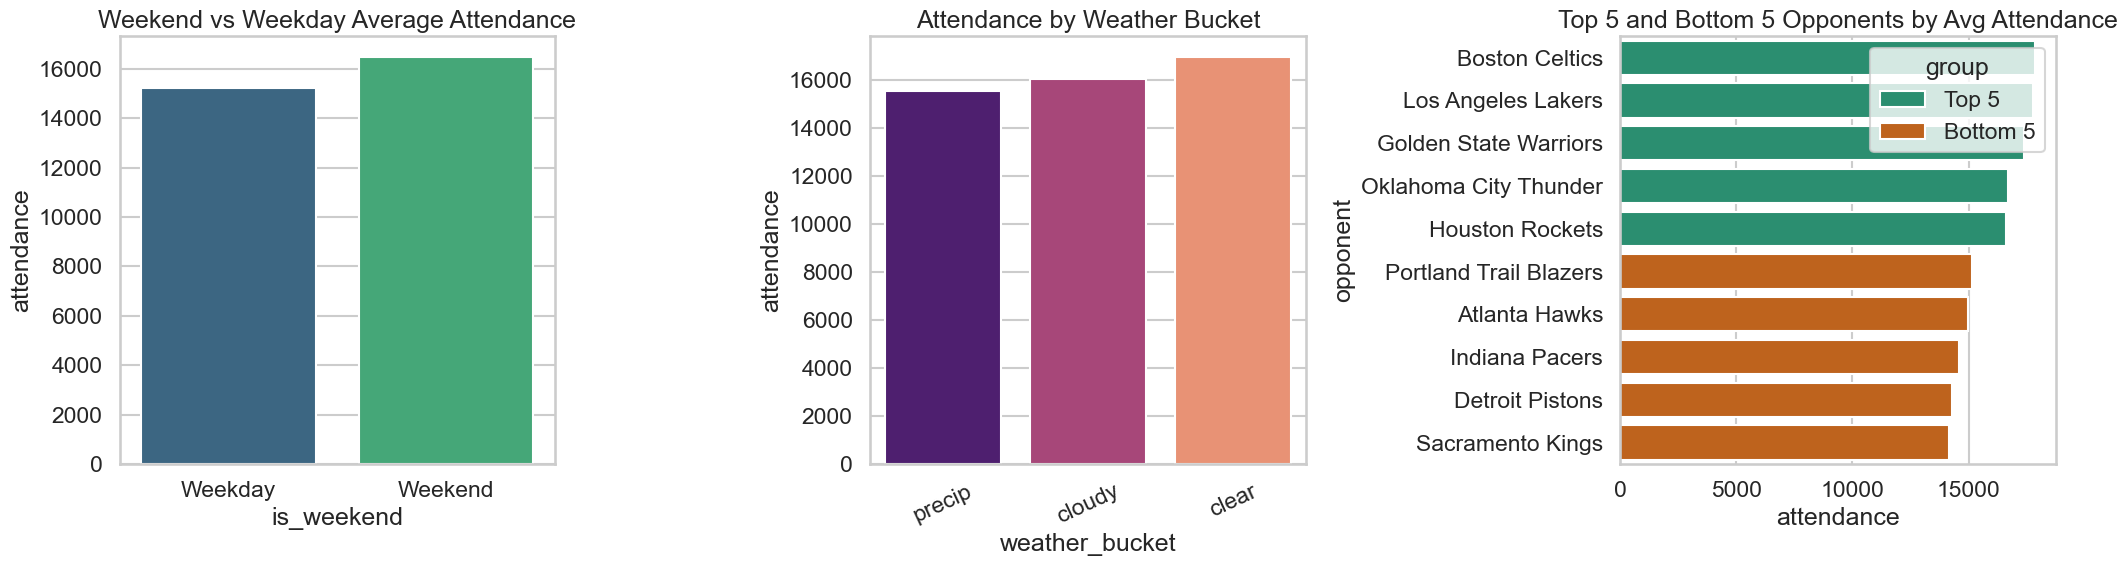

,metric,value
0,Overall avg attendance,"15,874.12"
1,Weekday avg attendance,"15,236.89"
2,Weekend avg attendance,"16,495.49"
3,Marquee avg attendance,"18,258.25"
4,Weak-opponent avg attendance,"15,415.43"


In [8]:
# Exploratory Data Analysis (presentation-quality)
eda = model_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(eda["attendance"], kde=True, bins=25, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Attendance Distribution")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=eda, x="day_of_week", y="attendance", order=dow_order, ax=axes[0, 1], palette="Set2")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].set_title("Attendance by Day of Week")

sns.boxplot(data=eda, x="opponent_quality_tier", y="attendance", order=["weak", "mid", "marquee"], ax=axes[1, 0], palette="coolwarm")
axes[1, 0].set_title("Attendance by Opponent Quality Tier")

yearly = eda.groupby("year", as_index=False)["attendance"].mean()
sns.lineplot(data=yearly, x="year", y="attendance", marker="o", ax=axes[1, 1], color="#2ca02c")
axes[1, 1].set_title("Average Attendance by Year")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.barplot(data=eda, x="is_weekend", y="attendance", estimator=np.mean, errorbar=None, ax=axes[0], palette="viridis")
axes[0].set_xticklabels(["Weekday", "Weekend"])
axes[0].set_title("Weekend vs Weekday Average Attendance")

sns.barplot(data=eda, x="weather_bucket", y="attendance", estimator=np.mean, errorbar=None, ax=axes[1], palette="magma")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_title("Attendance by Weather Bucket")

opp_rank = eda.groupby("opponent", as_index=False)["attendance"].mean().sort_values("attendance", ascending=False)
plot_df = pd.concat([opp_rank.head(5), opp_rank.tail(5)]).copy()
plot_df["group"] = ["Top 5"] * 5 + ["Bottom 5"] * 5
sns.barplot(data=plot_df, y="opponent", x="attendance", hue="group", dodge=False, ax=axes[2], palette={"Top 5": "#1b9e77", "Bottom 5": "#d95f02"})
axes[2].set_title("Top 5 and Bottom 5 Opponents by Avg Attendance")

plt.tight_layout()
plt.show()

# Compact summary table for slide support
eda_summary = pd.DataFrame({
    "metric": [
        "Overall avg attendance",
        "Weekday avg attendance",
        "Weekend avg attendance",
        "Marquee avg attendance",
        "Weak-opponent avg attendance"
    ],
    "value": [
        eda["attendance"].mean(),
        eda.loc[eda["is_weekday"] == 1, "attendance"].mean(),
        eda.loc[eda["is_weekend"] == 1, "attendance"].mean(),
        eda.loc[eda["is_marquee_opponent"] == 1, "attendance"].mean(),
        eda.loc[eda["is_weak_opponent"] == 1, "attendance"].mean(),
    ]
})
display(eda_summary)


### EDA Business Takeaways
- Attendance varies substantially by schedule context and opponent tier, supporting a predictive approach.
- Weekend and marquee effects are visible in grouped summaries.
- Weather appears to amplify downside risk more strongly in weaker-demand game contexts.
- Opponent-level spread indicates meaningful game-level revenue risk and upside opportunity.


In [9]:
# Modeling strategy and leakage control
# Target
target = "attendance"

# Exclude known leakage or post-game information
leakage_keywords = [
    "attendance_percent", "hornets_score", "opponent_score", "top_scorer", "most_assists", "top_rebounder",
    "capacity"
]

candidate_features = [
    "opponent", "opponent_clean", "season", "year", "month", "day_of_week",
    "is_weekend", "is_weekday", "is_holiday_window", "is_school_break_proxy",
    "days_since_prev_home_game", "dense_schedule_flag",
    "opponent_all_stars_count_final", "opponent_has_all_star",
    "opponent_quality_tier", "is_marquee_opponent", "is_weak_opponent", "premium_matchup_flag",
    "hornets_win_pct_proxy", "opponent_win_pct_proxy",
    "temp_high", "temp_low", "avg_temp", "precipitation", "wind_speed", "windy",
    "rain_flag", "bad_weather_flag", "severe_weather_flag", "weather_bucket",
    "weekday_x_weak_opp", "weekday_x_bad_weather", "non_marquee_x_bad_weather",
    "weekend_x_marquee", "weak_opp_x_rain"
]

feature_cols = [c for c in candidate_features if c in model_df.columns]
feature_cols = [
    c for c in feature_cols
    if not any(k in c.lower() for k in leakage_keywords)
]

data = model_df[["game_date", target] + feature_cols].copy().sort_values("game_date")

# Time-aware split to mimic forward prediction
split_idx = int(len(data) * 0.80)
train_df = data.iloc[:split_idx].copy()
test_df = data.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]
X_test = test_df[feature_cols]
y_test = test_df[target]

categorical_cols = [c for c in feature_cols if X_train[c].dtype == "object"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0, keep_empty_features=True))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown", keep_empty_features=True)),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb)
])

print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Numeric features:", len(numeric_cols), "| Categorical features:", len(categorical_cols))
print("Features used:")
print(feature_cols)


Train rows: 380 | Test rows: 96
Numeric features: 30 | Categorical features: 5
Features used:
['opponent', 'opponent_clean', 'season', 'year', 'month', 'day_of_week', 'is_weekend', 'is_weekday', 'is_holiday_window', 'is_school_break_proxy', 'days_since_prev_home_game', 'dense_schedule_flag', 'opponent_all_stars_count_final', 'opponent_has_all_star', 'opponent_quality_tier', 'is_marquee_opponent', 'is_weak_opponent', 'premium_matchup_flag', 'hornets_win_pct_proxy', 'opponent_win_pct_proxy', 'temp_high', 'temp_low', 'avg_temp', 'precipitation', 'wind_speed', 'windy', 'rain_flag', 'bad_weather_flag', 'severe_weather_flag', 'weather_bucket', 'weekday_x_weak_opp', 'weekday_x_bad_weather', 'non_marquee_x_bad_weather', 'weekend_x_marquee', 'weak_opp_x_rain']


In [10]:
# GridSearchCV tuning for XGBoost
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.07, 0.10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3],
    "model__gamma": [0, 0.2],
    "model__reg_alpha": [0, 0.1],
    "model__reg_lambda": [1, 2]
}

# TimeSeriesSplit avoids leakage from future to past during CV
tscv = TimeSeriesSplit(n_splits=4)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Params:")
print(grid.best_params_)
print(f"Best CV RMSE: {-grid.best_score_:,.2f}")


Fitting 4 folds for each of 1152 candidates, totalling 4608 fits
Best Params:
{'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.07, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 400, 'model__reg_alpha': 0, 'model__reg_lambda': 1, 'model__subsample': 0.8}
Best CV RMSE: 3,845.27


In [ ]:
# Model evaluation on holdout test set
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
try:
    rmse = mean_squared_error(y_test, y_pred, squared=False)
except TypeError:
    # Backward/forward compatibility across scikit-learn versions
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / np.clip(np.abs(y_test), a_min=1, a_max=None))) * 100

metrics_df = pd.DataFrame({
    "metric": ["R2", "RMSE", "MAE", "MAPE (%)"],
    "value": [r2, rmse, mae, mape]
})
display(metrics_df)

# Visual diagnostics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Attendance")
axes[0].set_ylabel("Predicted Attendance")

resid = y_test - y_pred
axes[1].scatter(y_pred, resid, alpha=0.7, color="#ff7f0e")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Attendance")
axes[1].set_ylabel("Residual")

sns.histplot(resid, bins=20, kde=True, ax=axes[2], color="#2ca02c")
axes[2].set_title("Prediction Error Distribution")

plt.tight_layout()
plt.show()

# Feature importance via built-in gain and permutation
pre = best_model.named_steps["preprocess"]
mod = best_model.named_steps["model"]

feature_names = pre.get_feature_names_out()
importances = mod.feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

display(fi.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=fi.head(15), y="feature", x="importance", palette="Blues_r")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

perm = permutation_importance(best_model, X_test, y_test, n_repeats=15, random_state=42, scoring="neg_root_mean_squared_error")
perm_df = pd.DataFrame({"feature": feature_cols, "perm_importance": perm.importances_mean}).sort_values("perm_importance", ascending=False)
print("Permutation importance (raw feature level):")
display(perm_df.head(15))

# Optional SHAP summary
if SHAP_AVAILABLE:
    try:
        X_train_t = pre.transform(X_train)
        X_test_t = pre.transform(X_test)
        explainer = shap.TreeExplainer(mod)
        shap_values = explainer.shap_values(X_test_t)

        shap.summary_plot(shap_values, X_test_t, feature_names=feature_names, show=False)
        plt.title("SHAP Summary Plot")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("SHAP section skipped due to runtime issue:", e)
else:
    print("SHAP not installed; skipped SHAP plots.")

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
# Business insight extraction (calculated from actual data/model)
biz = model_df.copy()

# Add model predictions for all rows where features are available
X_all = biz[feature_cols].copy()
biz["predicted_attendance"] = best_model.predict(X_all)

# Context averages
weekday_weak = biz.loc[(biz["is_weekday"] == 1) & (biz["is_weak_opponent"] == 1), "attendance"].mean()
weekday_marquee = biz.loc[(biz["is_weekday"] == 1) & (biz["is_marquee_opponent"] == 1), "attendance"].mean()
weekend_weak = biz.loc[(biz["is_weekend"] == 1) & (biz["is_weak_opponent"] == 1), "attendance"].mean()
weekend_marquee = biz.loc[(biz["is_weekend"] == 1) & (biz["is_marquee_opponent"] == 1), "attendance"].mean()

weekend_vs_weekday_diff = biz.loc[biz["is_weekend"] == 1, "attendance"].mean() - biz.loc[biz["is_weekday"] == 1, "attendance"].mean()
marquee_vs_weak_diff = biz.loc[biz["is_marquee_opponent"] == 1, "attendance"].mean() - biz.loc[biz["is_weak_opponent"] == 1, "attendance"].mean()

opp_avg = biz.groupby("opponent", as_index=False)["attendance"].mean().sort_values("attendance", ascending=False)
top5 = opp_avg.head(5)
bottom5 = opp_avg.tail(5)
top5_bottom5_spread = top5["attendance"].mean() - bottom5["attendance"].mean()

weather_impact_overall = biz.loc[biz["bad_weather_flag"] == 1, "attendance"].mean() - biz.loc[biz["bad_weather_flag"] == 0, "attendance"].mean()

weak_context = biz[biz["is_weak_opponent"] == 1]
weather_impact_weak = weak_context.loc[weak_context["bad_weather_flag"] == 1, "attendance"].mean() - weak_context.loc[weak_context["bad_weather_flag"] == 0, "attendance"].mean()

worst_combo_mask = (biz["is_weekday"] == 1) & (biz["is_weak_opponent"] == 1) & (biz["bad_weather_flag"] == 1)
best_combo_mask = (biz["is_weekend"] == 1) & (biz["is_marquee_opponent"] == 1) & (biz["bad_weather_flag"] == 0)

worst_case_attendance = biz.loc[worst_combo_mask, "attendance"].mean()
best_case_attendance = biz.loc[best_combo_mask, "attendance"].mean()
context_swing = best_case_attendance - worst_case_attendance

insight_table = pd.DataFrame({
    "metric": [
        "Avg attendance: Weekday + Weak Opponent",
        "Avg attendance: Weekday + Marquee Opponent",
        "Avg attendance: Weekend + Weak Opponent",
        "Avg attendance: Weekend + Marquee Opponent",
        "Weekend - Weekday attendance difference",
        "Marquee - Weak opponent attendance difference",
        "Top5 - Bottom5 opponent avg attendance spread",
        "Weather impact overall (bad - good)",
        "Weather impact in weak-opponent context (bad - good)",
        "Worst-case attendance (weekday + weak + bad weather)",
        "Best-case attendance (weekend + marquee + good weather)",
        "Best-vs-Worst context attendance swing"
    ],
    "value": [
        weekday_weak,
        weekday_marquee,
        weekend_weak,
        weekend_marquee,
        weekend_vs_weekday_diff,
        marquee_vs_weak_diff,
        top5_bottom5_spread,
        weather_impact_overall,
        weather_impact_weak,
        worst_case_attendance,
        best_case_attendance,
        context_swing
    ]
})

display(insight_table)
print("Top 5 opponents by average attendance")
display(top5)
print("Bottom 5 opponents by average attendance")
display(bottom5)


In [ ]:
# Revenue opportunity modeling (editable assumptions)
revenue_assumptions = {
    "avg_revenue_per_attendee": 95.0,         # dollars per attendee (tickets + in-arena spend proxy)
    "lift_rate_conservative": 0.05,           # 5% attendance lift on flagged low-demand games
    "lift_rate_base": 0.08,                   # 8% lift
    "lift_rate_optimistic": 0.12,             # 12% lift
    "low_demand_threshold_quantile": 0.30     # bottom 30% predicted attendance treated as low-demand risk
}

biz_rev = biz.copy()
threshold = biz_rev["predicted_attendance"].quantile(revenue_assumptions["low_demand_threshold_quantile"])
biz_rev["low_demand_flag"] = (biz_rev["predicted_attendance"] <= threshold).astype(int)

low_games = biz_rev[biz_rev["low_demand_flag"] == 1].copy()
low_games["attendance_gap_to_median"] = biz_rev["predicted_attendance"].median() - low_games["predicted_attendance"]
low_games["attendance_gap_to_median"] = low_games["attendance_gap_to_median"].clip(lower=0)

scenario_rows = []
for name, lift_col in [("Conservative", "lift_rate_conservative"), ("Base", "lift_rate_base"), ("Optimistic", "lift_rate_optimistic")]:
    lift = revenue_assumptions[lift_col]
    recovered_attendees_per_game = low_games["predicted_attendance"] * lift
    recovered_revenue_per_game = recovered_attendees_per_game * revenue_assumptions["avg_revenue_per_attendee"]

    scenario_rows.append({
        "scenario": name,
        "flagged_low_demand_games": len(low_games),
        "avg_predicted_attendance_flagged": low_games["predicted_attendance"].mean(),
        "avg_recovered_attendees_per_game": recovered_attendees_per_game.mean(),
        "avg_recovered_revenue_per_game": recovered_revenue_per_game.mean(),
        "seasonal_recovered_attendees": recovered_attendees_per_game.sum(),
        "seasonal_recovered_revenue": recovered_revenue_per_game.sum()
    })

scenario_df = pd.DataFrame(scenario_rows)
display(pd.DataFrame(revenue_assumptions.items(), columns=["assumption", "value"]))
display(scenario_df)

# Export for slide support
scenario_df.to_csv("revenue_scenarios_for_presentation.csv", index=False)


In [ ]:
# High-risk game flagging operational table
ops = biz.copy()

# Demand tiers by predicted attendance tertiles
low_cut = ops["predicted_attendance"].quantile(0.33)
high_cut = ops["predicted_attendance"].quantile(0.67)

def demand_tier(p):
    if p <= low_cut:
        return "Low"
    if p >= high_cut:
        return "High"
    return "Medium"

ops["demand_tier"] = ops["predicted_attendance"].apply(demand_tier)
ops["low_demand_risk_flag"] = (ops["demand_tier"] == "Low").astype(int)

# Simple explainable risk tags
risk_tags = []
for _, r in ops.iterrows():
    tags = []
    if r.get("is_weekday", 0) == 1:
        tags.append("Weekday")
    if r.get("is_weak_opponent", 0) == 1:
        tags.append("Weak Opponent")
    if r.get("bad_weather_flag", 0) == 1:
        tags.append("Bad Weather")
    if r.get("dense_schedule_flag", 0) == 1:
        tags.append("Dense Schedule")
    if len(tags) == 0:
        tags.append("No major risk signal")
    risk_tags.append(", ".join(tags))

ops["key_explanatory_factors"] = risk_tags

operational_table = ops[[
    "game_date", "opponent", "day_of_week", "predicted_attendance", "attendance",
    "demand_tier", "low_demand_risk_flag", "key_explanatory_factors"
]].sort_values("predicted_attendance")

operational_table = operational_table.rename(columns={
    "game_date": "game_date",
    "opponent": "opponent",
    "day_of_week": "day_of_week",
    "predicted_attendance": "predicted_attendance",
    "attendance": "actual_attendance"
})

display(operational_table.head(25))

operational_table.to_csv("high_risk_game_flags_for_ops.csv", index=False)


In [ ]:
# Presentation Numbers to Update
print("# Presentation Numbers to Update")

# Core model metrics
print("\nModel Metrics (Holdout Test)")
print(metrics_df.to_string(index=False))

# Insight metrics for slides
print("\nUpdated Averages and Effects")
print(insight_table.to_string(index=False))

# Additional presentation-ready values
seat_gap_weekday_weak_vs_overall = biz["attendance"].mean() - weekday_weak
seat_gap_worst_vs_best = context_swing
feature_top = fi.head(10).copy()

presentation_numbers = pd.DataFrame({
    "item": [
        "Overall Avg Attendance",
        "Weekday Weak-Opp Avg Attendance",
        "Weekday Marquee Avg Attendance",
        "Weekend Weak-Opp Avg Attendance",
        "Weekend Marquee Avg Attendance",
        "Weekend Effect (Weekend - Weekday)",
        "Marquee Effect (Marquee - Weak)",
        "Top5 vs Bottom5 Opponent Spread",
        "Seat Gap: Overall vs Weekday+Weak",
        "Worst-vs-Best Context Swing",
        "High-Risk Threshold (Predicted Attendance)",
        "Low-Demand Games Flagged"
    ],
    "value": [
        biz["attendance"].mean(),
        weekday_weak,
        weekday_marquee,
        weekend_weak,
        weekend_marquee,
        weekend_vs_weekday_diff,
        marquee_vs_weak_diff,
        top5_bottom5_spread,
        seat_gap_weekday_weak_vs_overall,
        seat_gap_worst_vs_best,
        low_cut,
        (ops["low_demand_risk_flag"] == 1).sum()
    ]
})

display(presentation_numbers)
print("\nTop Feature Importance Signals")
display(feature_top)

print("\nRevenue Recovery Range")
display(scenario_df[["scenario", "seasonal_recovered_revenue", "seasonal_recovered_attendees"]])


In [ ]:
# Optional reusable scorer for future games

def score_future_games(future_games_df: pd.DataFrame, trained_model, feature_columns, reference_df: pd.DataFrame) -> pd.DataFrame:
    # Score future games with the trained pipeline.
    # Expects fields for game_date/date, opponent, and optional weather/context fields.
    # Missing engineered fields are created with defaults.
    future = future_games_df.copy()

    # Date parsing
    dt_col = "game_date" if "game_date" in future.columns else ("date" if "date" in future.columns else None)
    if dt_col is None:
        raise ValueError("Future games need a game_date or date column.")

    future["game_date"] = pd.to_datetime(future[dt_col], errors="coerce")
    future["year"] = future["game_date"].dt.year
    future["month"] = future["game_date"].dt.month
    future["day_of_week"] = future["game_date"].dt.day_name()
    future["is_weekend"] = future["day_of_week"].isin(["Friday", "Saturday", "Sunday"]).astype(int)
    future["is_weekday"] = 1 - future["is_weekend"]
    future["is_holiday_window"] = future["month"].isin([11, 12, 1]).astype(int)
    future["is_school_break_proxy"] = future["month"].isin([12, 6, 7, 8]).astype(int)

    if "opponent" in future.columns:
        future["opponent_clean"] = future["opponent"].apply(clean_team_name)
    else:
        future["opponent"] = "unknown"
        future["opponent_clean"] = "unknown"

    # Fill any missing engineered columns with sensible defaults from historical medians/modes
    for col in feature_columns:
        if col not in future.columns:
            if col in reference_df.columns and pd.api.types.is_numeric_dtype(reference_df[col]):
                future[col] = reference_df[col].median()
            elif col in reference_df.columns:
                future[col] = reference_df[col].mode().iloc[0] if not reference_df[col].mode().empty else "unknown"
            else:
                future[col] = 0

    future["predicted_attendance"] = trained_model.predict(future[feature_columns])
    return future

print("Reusable function score_future_games() is ready.")


## Executive Summary
- Attendance is forecastable with meaningful accuracy using pre-game context.
- Opponent quality and scheduling context are major drivers; weather amplifies downside for weaker-demand games.
- Low-demand games can be flagged in advance and linked to intervention playbooks.
- Scenario modeling converts attendance lift assumptions into explicit revenue-recovery ranges for leadership planning.

### Files Exported for Presentation Support
- revenue_scenarios_for_presentation.csv
- high_risk_game_flags_for_ops.csv
